In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# !pip install tensorflow
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation,Dense,Flatten,BatchNormalization,Conv2D,MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import itertools
import os
import shutil
import random
import glob
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore',category=FutureWarning)
%matplotlib inline

In [15]:
extract_path = "/content/drive/MyDrive/wheat_leaf_generated_modified"
if os.path.exists(extract_path):
    print("Extracted files:", os.listdir(extract_path))
else:
    print("Extraction failed or path incorrect.")

Extracted files: ['Validation', 'Training', 'Testing']


In [17]:
for root, dirs, files in os.walk("/content/drive/MyDrive/wheat_leaf_generated_mdified"):
    print(root, dirs, files)

In [18]:
training_path='/content/drive/MyDrive/wheat_leaf_generated_modified/Training'
validation_path='/content/drive/MyDrive/wheat_leaf_generated_modified/Validation'
testing_path='/content/drive/MyDrive/wheat_leaf_generated_modified/Testing'

In [19]:
print("Training path:", training_path)
print("Validation path:", validation_path)
print("Testing path:", testing_path)

Training path: /content/drive/MyDrive/wheat_leaf_generated_modified/Training
Validation path: /content/drive/MyDrive/wheat_leaf_generated_modified/Validation
Testing path: /content/drive/MyDrive/wheat_leaf_generated_modified/Testing


In [118]:
train_batches=ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(training_path, target_size=(224,224), classes=['Healthy Generated', 'Septoria Generated', 'Stripe Rust Generated'], batch_size=64)

valid_batches=ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(validation_path, target_size=(224,224), classes=['Healthy Generated', 'Septoria Generated', 'Stripe Rust Generated'], batch_size=64)

test_batches=ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(testing_path, target_size=(224,224), classes=['Healthy Generated', 'Septoria Generated', 'Stripe Rust Generated'], batch_size=64)

Found 240 images belonging to 3 classes.
Found 30 images belonging to 3 classes.
Found 30 images belonging to 3 classes.


In [119]:
# Preview a batch
x_batch, y_batch = next(train_batches)
print("Image shape:", x_batch.shape)
print("Pixel range (min to max):", x_batch.min(), "to", x_batch.max())


Image shape: (64, 224, 224, 3)
Pixel range (min to max): -71.939 to 94.061


In [120]:

# plots images with labels within jupyter notebook
def plots(ims, figsize=(12,6), rows=1, interp=False, titles=None):
    if type(ims[0]) is np.ndarray:
        ims = np.array(ims).astype(np.uint8)
        if (ims.shape[-1] != 3):
            ims = ims.transpose((0,2,3,1))
    f = plt.figure(figsize=figsize)
    cols = len(ims)//rows if len(ims) % 2 == 0 else len(ims)//rows + 1
    for i in range(len(ims)):
        sp = f.add_subplot(rows, cols, i+1)
        sp.axis('Off')
        if titles is not None:
            sp.set_title(titles[i], fontsize=16)
        plt.imshow(ims[i], interpolation=None if interp else 'none')

In [121]:
imgs, labels = next(train_batches)

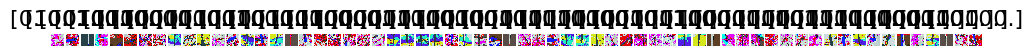

In [122]:
plots(imgs, titles=labels)

Build and train CNN

In [123]:
model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(224,224,3)),
        Flatten(),
        Dense(3, activation='softmax'),
    ])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [124]:
model.compile(Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

In [125]:
# Define early stopping
early_stopping = EarlyStopping(
    monitor='val_accuracy',     # Metric to monitor
    patience=10,             # Number of epochs to wait after no improvement
    verbose=1,              # Verbosity mode
    restore_best_weights=True # Restore the best weights after stopping
)

In [126]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1577088)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │     4,731,267 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,732,163 (18.05 MB)

 Trainable params: 4,732,163 (18.05 MB)

 Non-trainable params: 0 (0.00 B)

In [127]:
model.fit(train_batches, validation_data=valid_batches, epochs=50, callbacks=[early_stopping], verbose=2)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
4/4 - 4s - 1s/step - accuracy: 0.3625 - loss: 27822.9570 - val_accuracy: 0.6000 - val_loss: 22101.8086
Epoch 2/50
4/4 - 1s - 358ms/step - accuracy: 0.5958 - loss: 10417.6836 - val_accuracy: 0.4000 - val_loss: 23665.3730
Epoch 3/50
4/4 - 3s - 771ms/step - accuracy: 0.7125 - loss: 5129.3350 - val_accuracy: 0.6000 - val_loss: 3956.1685
Epoch 4/50
4/4 - 2s - 565ms/step - accuracy: 0.9417 - loss: 1130.4644 - val_accuracy: 0.7667 - val_loss: 2854.7610
Epoch 5/50
4/4 - 2s - 389ms/step - accuracy: 0.9792 - loss: 328.1587 - val_accuracy: 0.9333 - val_loss: 2128.5671
Epoch 6/50
4/4 - 2s - 413ms/step - accuracy: 0.9167 - loss: 823.8642 - val_accuracy: 0.8667 - val_loss: 2299.4153
Epoch 7/50
4/4 - 3s - 667ms/step - accuracy: 0.9625 - loss: 601.9214 - val_accuracy: 0.9667 - val_loss: 21.3344
Epoch 8/50
4/4 - 2s - 404ms/step - accuracy: 0.9708 - loss: 888.3209 - val_accuracy: 0.8667 - val_loss: 3801.6416
Epoch 9/50
4/4 - 2s - 386ms/step - accuracy: 0.9833 - loss: 133.4157 - val_accuracy: 

In [128]:
print(f"Stopped at epoch: {early_stopping.stopped_epoch}")


Stopped at epoch: 16


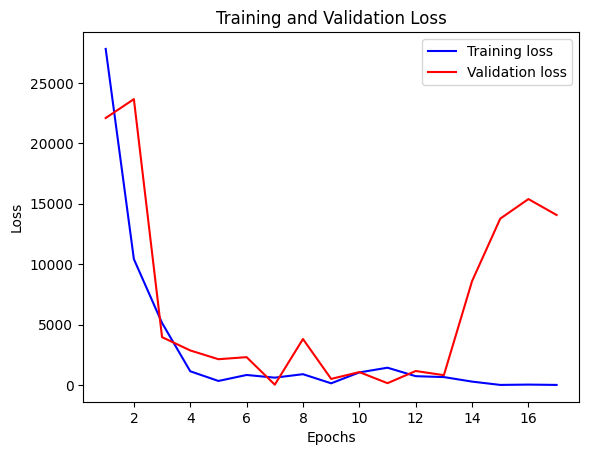

In [129]:
# prompt: plot training, testing and validation loss

import matplotlib.pyplot as plt

# Assuming 'history' object contains the training history from model.fit
# history = model.fit(...)

# Access the loss values
training_loss = model.history.history['loss']
validation_loss = model.history.history['val_loss']

# Plot the training and validation loss
epochs = range(1, len(training_loss) + 1)  # Assuming epochs are available

plt.plot(epochs, training_loss, 'b', label='Training loss')
plt.plot(epochs, validation_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


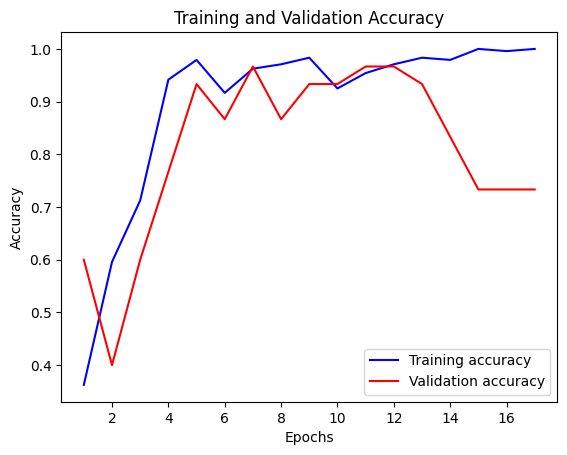

In [130]:
# Plot training and validation accuracy
training_accuracy = model.history.history['accuracy']
validation_accuracy = model.history.history['val_accuracy']

plt.plot(epochs, training_accuracy, 'b', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [131]:
# Evaluate on training set
train_loss, train_accuracy = model.evaluate(train_batches, verbose=0)
print(f"Training Loss: {train_loss:.4f}")
print(f"Training Accuracy: {train_accuracy*100:.2f}%")

# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(valid_batches, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_batches, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


Training Loss: 761.6668
Training Accuracy: 97.08%
Validation Loss: 21.3344
Validation Accuracy: 96.67%
Test Loss: 1134.2789
Test Accuracy: 90.00%


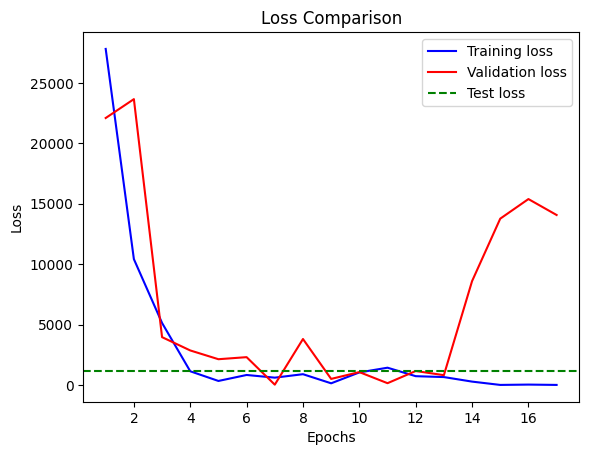

In [132]:
# Plot test loss and accuracy for comparison
plt.plot(epochs, training_loss, 'b', label='Training loss')
plt.plot(epochs, validation_loss, 'r', label='Validation loss')
plt.axhline(y=test_loss, color='g', linestyle='--', label='Test loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

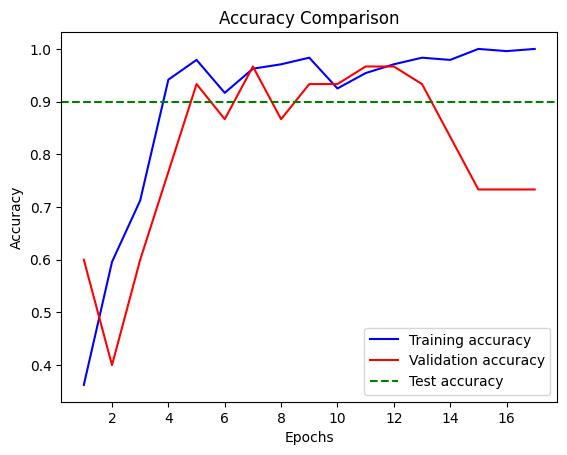

In [133]:
plt.plot(epochs, training_accuracy, 'b', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation accuracy')
plt.axhline(y=test_accuracy, color='g', linestyle='--', label='Test accuracy')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [134]:
test_imgs, test_labels = next(test_batches)

# Get the model predictions
predictions = model.predict(test_imgs)

# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=-1)

# Print actual vs predicted labels (indices)
print(f"Actual labels: {test_labels}")
print(f"Predicted labels (indices): {predicted_classes}")

# Optionally, print the class names:
class_names = ['Healthy', 'Septoria', 'Stripe_rust']
predicted_class_names = [class_names[i] for i in predicted_classes]
print(f"Predicted class names: {predicted_class_names}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
Actual labels: [[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Predicted labels (indices): [0 0 1 0 1 1 2 2 0 1 2 2 2 1 0 0 2 2 2 1 2 1 2 2 1 2 1 0 1 2]
Predicted class names: ['Healthy', 'Healthy', 'Septoria', 'Healthy', 'Septoria', 'Septoria', 'Stripe_rust', 'Stripe_rust', 'Healthy', 'Septoria', 'Stripe_rust', 'Stripe_rust', 'Stripe_rust', 'Septoria', 'Healthy', 'Healthy', 'Stripe_rust', 'Stripe_rust', 'Stripe_rust', 'Septoria', 'Stripe_rust', 'Septoria', 'Stripe_rust', 'Stripe_rust', 'Septoria', 'Stripe_rust', 'Septoria', 'Healthy', 'Septoria', 'Stripe_rust']


Predict


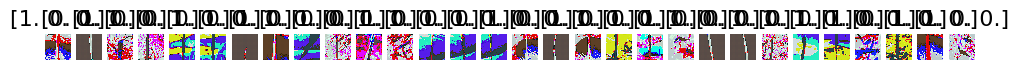

In [135]:
test_imgs, test_labels = next(test_batches)
plots(test_imgs, titles=test_labels)

In [136]:
test_labels = test_labels[:,0]
test_labels

array([1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0.,
       1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 1.], dtype=float32)

In [137]:
predictions = model.predict(test_batches, steps=1, verbose=0)

In [138]:

predictions.round(2)

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]], dtype=float32)

In [139]:
cm = confusion_matrix(test_labels, [np.argmax(i) for i in predictions])

In [140]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [141]:
print("Training classes:", os.listdir(training_path))
print("Validation classes:", os.listdir(validation_path))
print("Testing classes:", os.listdir(testing_path))


Training classes: ['Septoria Generated', 'Healthy Generated', 'Stripe Rust Generated']
Validation classes: ['Septoria Generated', 'Healthy Generated', 'Stripe Rust Generated']
Testing classes: ['Healthy Generated', 'Septoria Generated', 'Stripe Rust Generated']


Confusion matrix, without normalization
[[ 0 10 10]
 [ 7  0  3]
 [ 0  0  0]]


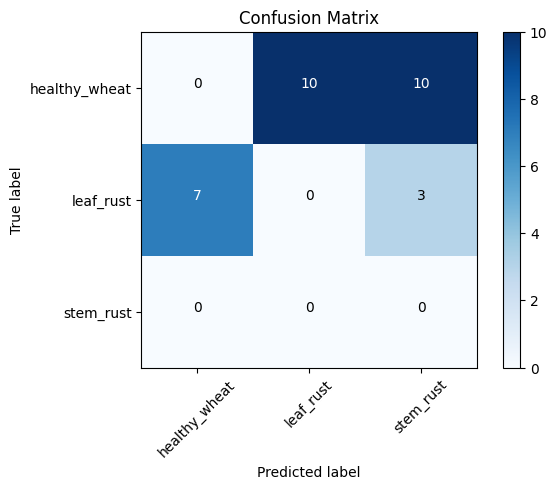

In [142]:
cm_plot_labels = ['healthy_wheat','leaf_rust','stem_rust']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix')

Build Fine-tuned VGG16 model

In [143]:
vgg16_model = keras.applications.vgg16.VGG16()

In [144]:
vgg16_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [145]:
type(vgg16_model)

keras.src.models.functional.Functional

In [146]:

model = Sequential()
for layer in vgg16_model.layers:
    model.add(layer)

In [147]:

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [148]:
model.layers.pop()

<Dense name=predictions, built=True>

In [149]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [150]:
for layer in model.layers:
    layer.trainable = False

In [152]:
model.add(Dense(3, activation='softmax'))

In [153]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │         3,003 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,360,559 (527.80 MB)

 Trainable params: 3,015 (11.78 KB)

 Non-trainable params: 138,357,544 (527.79 MB)

Train the fine-tuned VGG16 model

In [155]:
model.compile(Adam(learning_rate=.01), loss='categorical_crossentropy', metrics=['accuracy'])

In [156]:
history = model.fit(train_batches, steps_per_epoch=4,
                    validation_data=valid_batches, epochs=50, callbacks=[early_stopping], verbose=2)


Epoch 1/50
4/4 - 7s - 2s/step - accuracy: 0.3458 - loss: 1.1532 - val_accuracy: 0.3333 - val_loss: 1.1372
Epoch 2/50
4/4 - 2s - 611ms/step - accuracy: 0.3333 - loss: 1.1314 - val_accuracy: 0.3333 - val_loss: 1.1174
Epoch 3/50
4/4 - 2s - 546ms/step - accuracy: 0.3333 - loss: 1.1111 - val_accuracy: 0.3333 - val_loss: 1.1033
Epoch 4/50
4/4 - 2s - 559ms/step - accuracy: 0.3333 - loss: 1.0995 - val_accuracy: 0.3333 - val_loss: 1.0925
Epoch 5/50
4/4 - 3s - 648ms/step - accuracy: 0.3333 - loss: 1.0911 - val_accuracy: 0.3333 - val_loss: 1.0848
Epoch 6/50
4/4 - 2s - 621ms/step - accuracy: 0.3667 - loss: 1.0824 - val_accuracy: 0.3667 - val_loss: 1.0796
Epoch 7/50
4/4 - 3s - 728ms/step - accuracy: 0.5458 - loss: 1.0795 - val_accuracy: 0.5000 - val_loss: 1.0752
Epoch 8/50
4/4 - 2s - 568ms/step - accuracy: 0.5417 - loss: 1.0751 - val_accuracy: 0.4667 - val_loss: 1.0710
Epoch 9/50
4/4 - 3s - 693ms/step - accuracy: 0.4625 - loss: 1.0709 - val_accuracy: 0.4667 - val_loss: 1.0661
Epoch 10/50
4/4 - 2s -

In [157]:
!nvidia-smi

Sat Apr 19 17:21:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P0             40W /   70W |   14066MiB /  15360MiB |     19%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

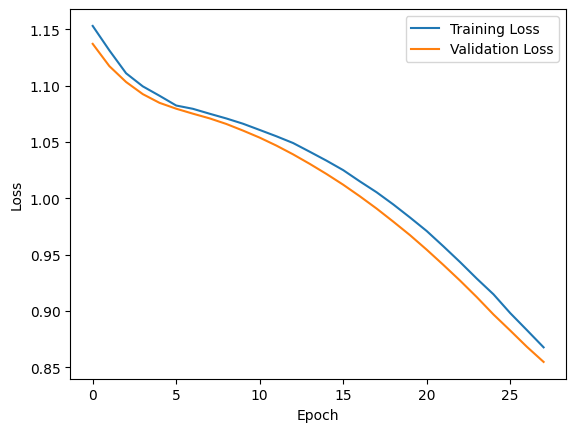

In [158]:
# prompt: Plot training and validation loss

# Plot training and validation loss
plt.plot(model.history.history['loss'], label='Training Loss')
plt.plot(model.history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


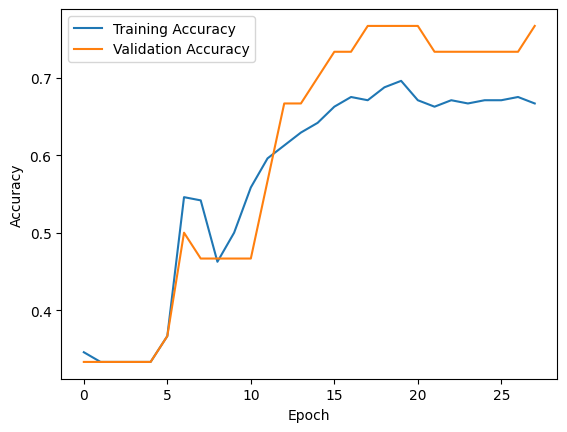

In [159]:
# prompt: plot training an validation accuracy

# Plot training and validation accuracy
plt.plot(model.history.history['accuracy'], label='Training Accuracy')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


Predict using fine-tuned VGG16 model

In [160]:
# Evaluate on training set
train_loss, train_accuracy = model.evaluate(train_batches, verbose=0)
print(f"Training Loss on VGG16: {train_loss:.4f}")
print(f"Training Accuracy on VGG16: {train_accuracy*100:.2f}%")

# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(valid_batches, verbose=0)
print(f"Validation Loss on VGG16: {val_loss:.4f}")
print(f"Validation Accuracy on VGG16: {val_accuracy*100:.2f}%")

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(test_batches, verbose=0)
print(f"Test Loss on VGG16: {test_loss:.4f}")
print(f"Test Accuracy on VGG16: {test_accuracy*100:.2f}%")


Training Loss on VGG16: 0.9983
Training Accuracy on VGG16: 68.75%
Validation Loss on VGG16: 0.9909
Validation Accuracy on VGG16: 76.67%
Test Loss on VGG16: 1.0071
Test Accuracy on VGG16: 76.67%


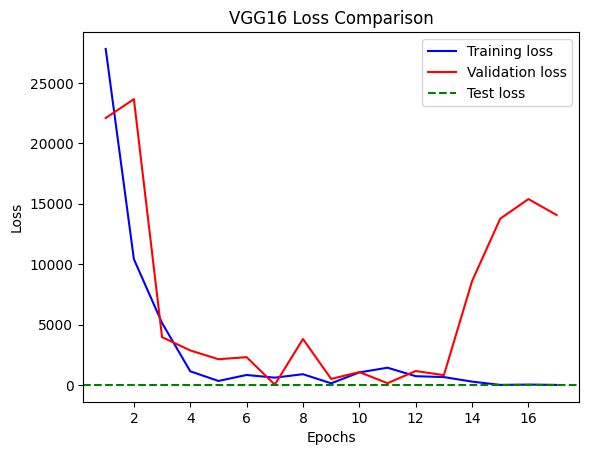

In [161]:
# Plot test loss and accuracy for comparison
plt.plot(epochs, training_loss, 'b', label='Training loss')
plt.plot(epochs, validation_loss, 'r', label='Validation loss')
plt.axhline(y=test_loss, color='g', linestyle='--', label='Test loss')
plt.title('VGG16 Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

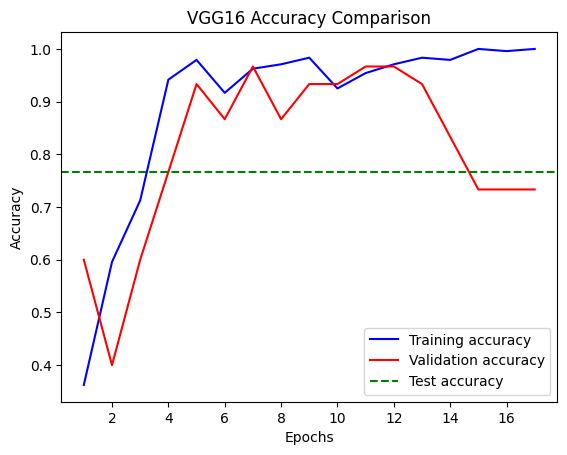

In [162]:
plt.plot(epochs, training_accuracy, 'b', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation accuracy')
plt.axhline(y=test_accuracy, color='g', linestyle='--', label='Test accuracy')
plt.title('VGG16 Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

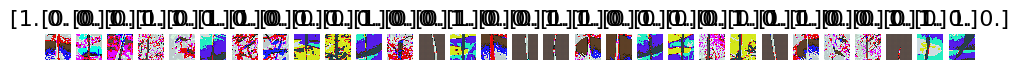

In [163]:

test_imgs, test_labels = next(test_batches)
plots(test_imgs, titles=test_labels)

In [164]:
test_labels = test_labels[:,0]
test_labels

array([1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0.,
       1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.], dtype=float32)

In [165]:

predictions = model.predict(test_batches, steps=1, verbose=0)

In [166]:
cm = confusion_matrix(test_labels, [np.argmax(i) for i in predictions])

Confusion matrix, without normalization
[[ 0 10 10]
 [ 3  3  4]
 [ 0  0  0]]


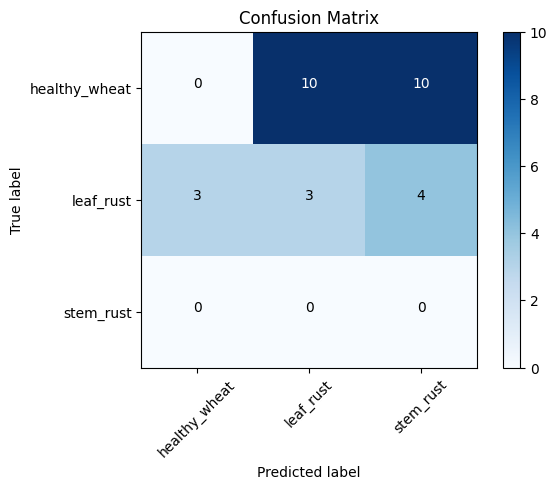

In [167]:

cm_plot_labels = ['healthy_wheat','leaf_rust','stem_rust']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix')

In [168]:
from sklearn.metrics import classification_report
cr=classification_report(test_labels, [np.argmax(i) for i in predictions],target_names=cm_plot_labels,)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [169]:
print(cr)

               precision    recall  f1-score   support

healthy_wheat       0.00      0.00      0.00        20
    leaf_rust       0.23      0.30      0.26        10
    stem_rust       0.00      0.00      0.00         0

     accuracy                           0.10        30
    macro avg       0.08      0.10      0.09        30
 weighted avg       0.08      0.10      0.09        30



In [170]:
model.evaluate(test_batches)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.7667 - loss: 1.0071


[1.0071219205856323, 0.7666666507720947]



```
# This is formatted as code
```



Histogram